**Import Libraries**

In [23]:
#Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Pre-Processing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

#Evaluation
from sklearn.metrics import r2_score

# Config
import warnings
warnings.filterwarnings('ignore')

**Load Data and EDA**

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Data Science/Projects/Kaggle - BlueBerry 2025/train.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15000 non-null  int64  
 1   Row#                  15000 non-null  float64
 2   clonesize             15000 non-null  float64
 3   honeybee              15000 non-null  float64
 4   bumbles               15000 non-null  float64
 5   andrena               15000 non-null  float64
 6   osmia                 15000 non-null  float64
 7   MaxOfUpperTRange      15000 non-null  float64
 8   MinOfUpperTRange      15000 non-null  float64
 9   AverageOfUpperTRange  15000 non-null  float64
 10  MaxOfLowerTRange      15000 non-null  float64
 11  MinOfLowerTRange      15000 non-null  float64
 12  AverageOfLowerTRange  15000 non-null  float64
 13  RainingDays           15000 non-null  float64
 14  AverageRainingDays    15000 non-null  float64
 15  fruitset           

In [4]:
# Dropping id Column as its not needed
df = df.drop(columns = 'id')

In [5]:
df.describe()

,Row#,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,428.047667,19.863667,0.392469,0.284537,0.486710,0.590889,82.180120,49.677500,68.665087,59.234267,28.664240,48.574627,18.858736,0.327872,0.499348,0.445122,36.021547,5999.695233
std,213.729146,6.657217,0.450947,0.058979,0.149067,0.146059,9.115977,5.528593,7.615925,6.592068,3.184226,5.374297,11.818525,0.166155,0.077570,0.038205,4.108004,1367.733014
min,0.000000,12.500000,0.000000,0.000000,0.000000,0.000000,68.200000,37.500000,58.200000,30.000000,24.300000,39.000000,1.000000,0.060000,0.192732,0.192732,18.436436,1637.704020
25%,249.000000,12.500000,0.250000,0.250000,0.380000,0.500000,77.400000,46.800000,64.700000,55.800000,27.000000,45.800000,16.000000,0.260000,0.450103,0.417915,33.228900,5042.640340
50%,468.000000,25.000000,0.500000,0.250000,0.500000,0.630000,86.000000,52.000000,71.900000,62.000000,30.000000,50.800000,16.000000,0.260000,0.502842,0.445484,35.923314,6072.834430
75%,597.000000,25.000000,0.500000,0.380000,0.630000,0.750000,86.000000,52.000000,71.900000,62.000000,30.000000,50.800000,24.000000,0.390000,0.559325,0.471650,38.868110,7028.673500
max,776.000000,40.000000,18.430000,0.630000,0.750000,0.750000,94.600000,57.200000,79.000000,68.200000,33.000000,62.000000,34.000000,0.560000,0.875989,0.707159,46.369344,8969.401840


In [6]:
df.head()

,Row#,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,286.0,12.5,0.25,0.25,0.63,0.50,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.477832,0.436997,34.781055,5329.26320
1,153.0,12.5,0.25,0.25,0.38,0.38,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.465199,0.408789,33.847539,5602.02293
2,479.0,25.0,0.50,0.25,0.38,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.496598,0.442529,35.558911,5018.45303
3,481.0,25.0,0.50,0.25,0.38,0.75,86.0,52.0,71.9,62.0,30.0,50.8,1.0,0.10,0.608455,0.503636,42.487539,7935.09476
4,517.0,25.0,0.50,0.25,0.50,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.429001,0.403130,31.597416,4905.49871


Check Null Values

In [7]:
df.isnull().sum()

,0
Row#,0
clonesize,0
honeybee,0
bumbles,0
andrena,0
osmia,0
MaxOfUpperTRange,0
MinOfUpperTRange,0
AverageOfUpperTRange,0
MaxOfLowerTRange,0


Check Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

Check For Outliers

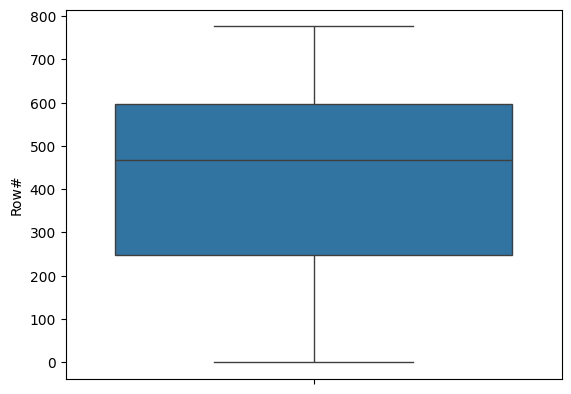

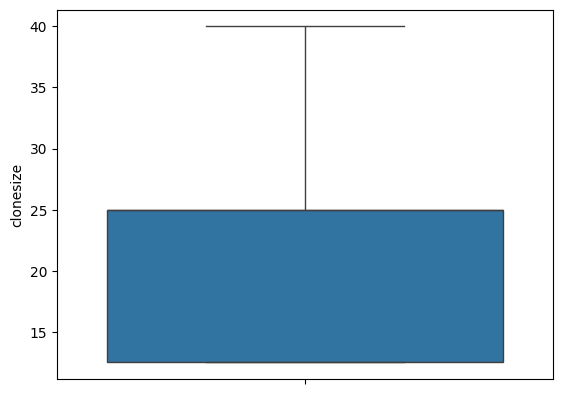

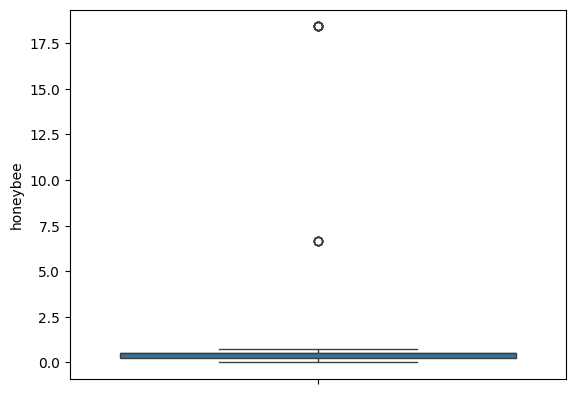

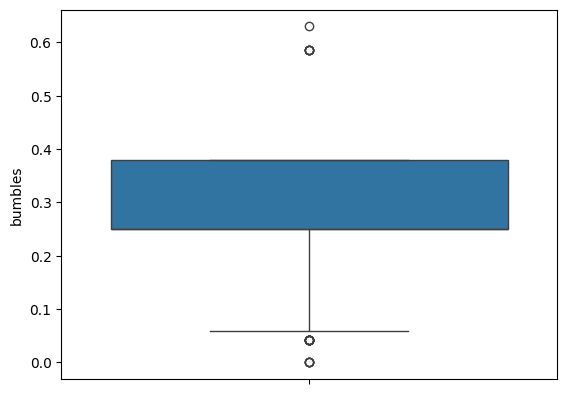

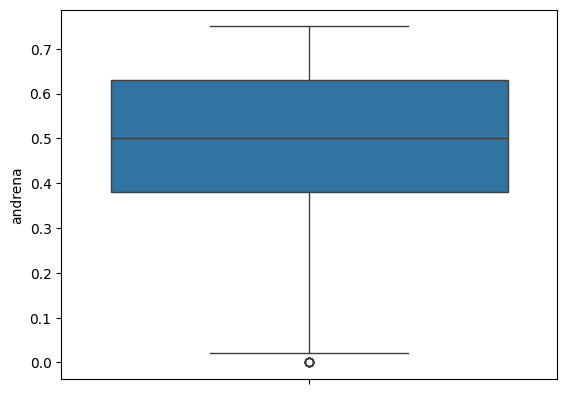

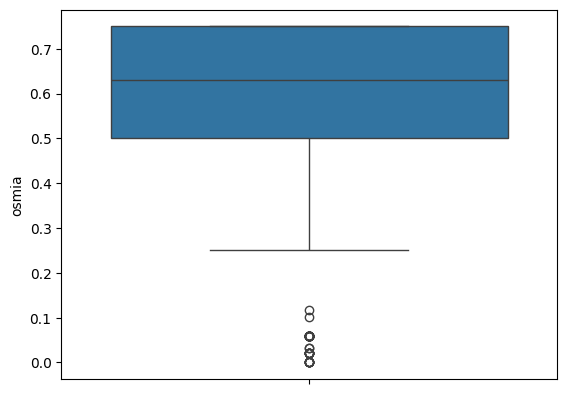

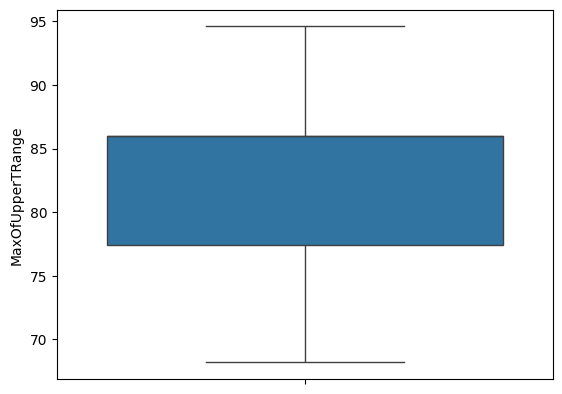

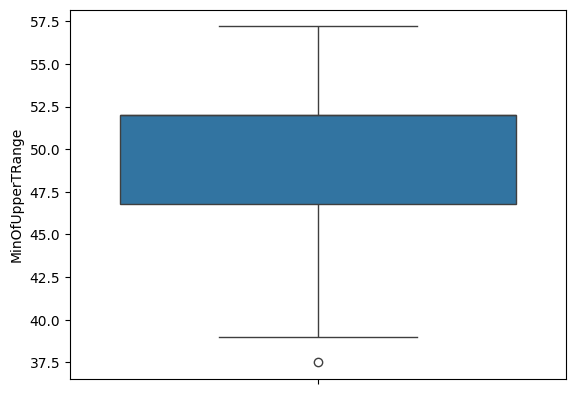

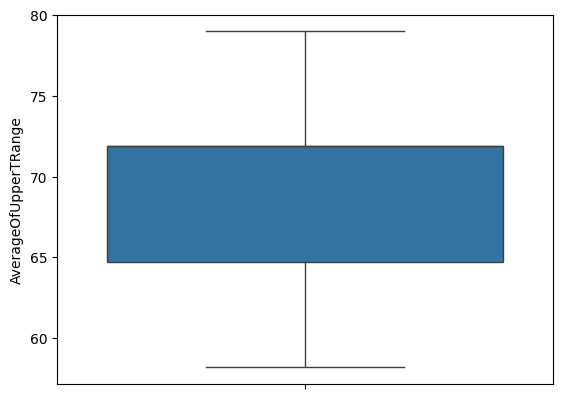

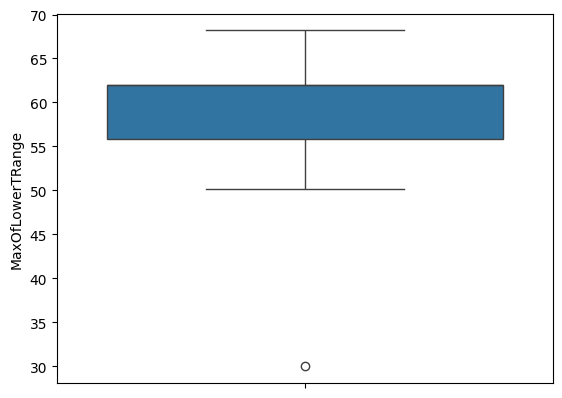

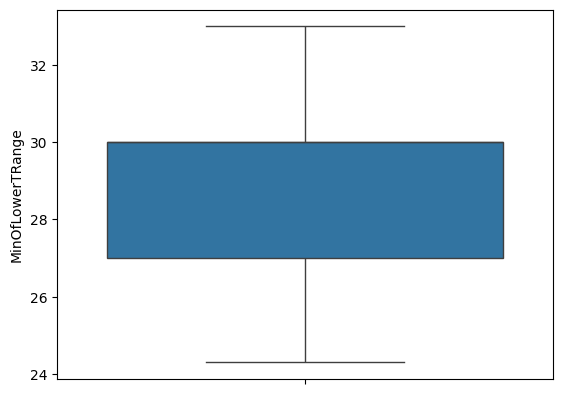

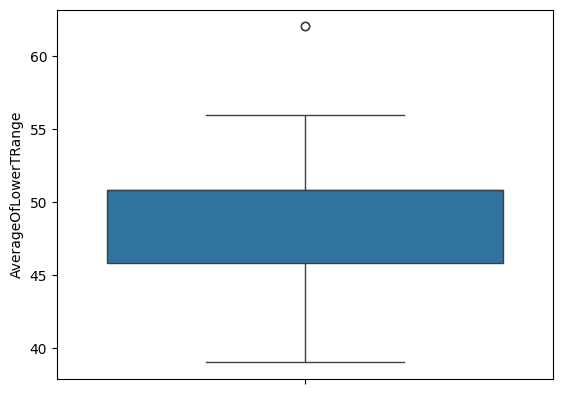

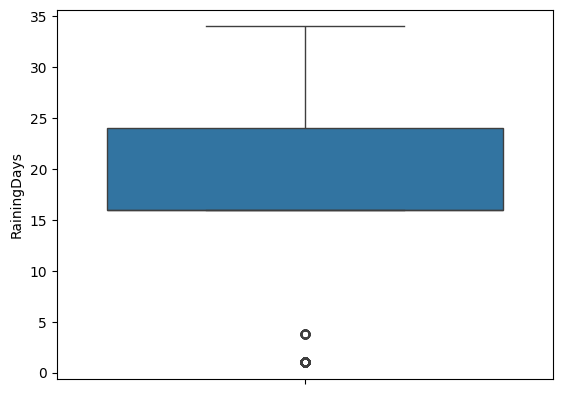

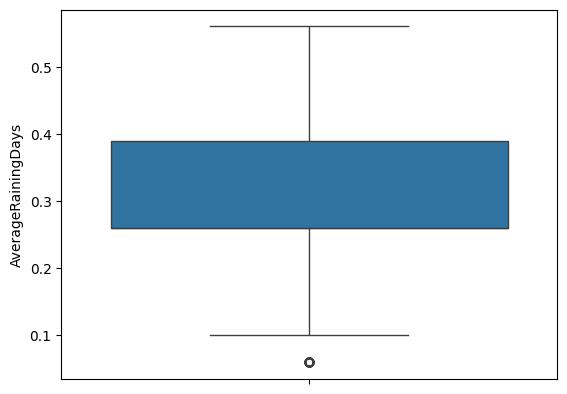

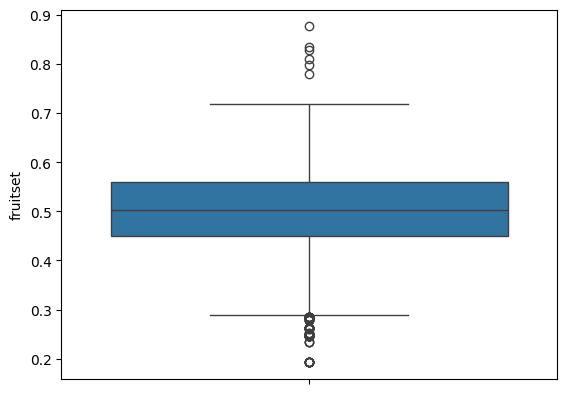

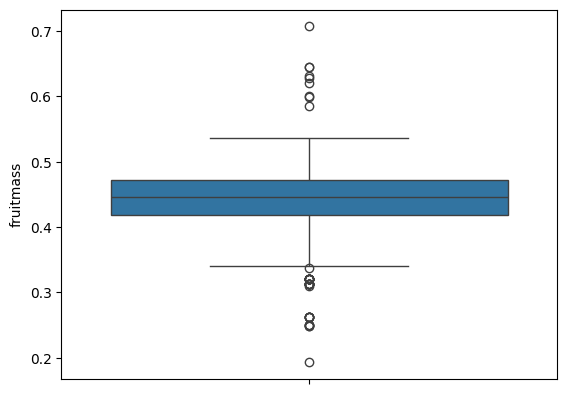

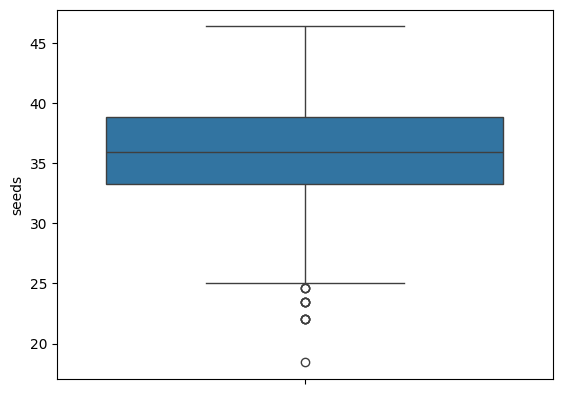

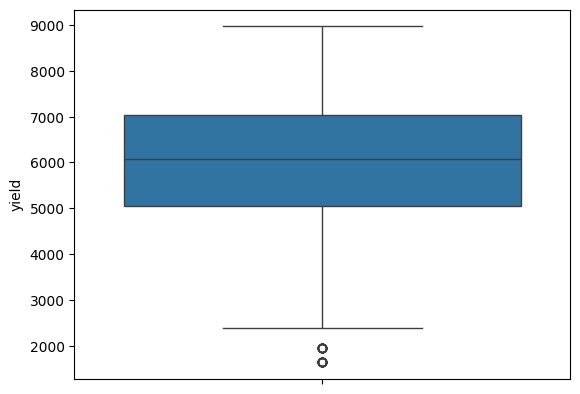

In [9]:
for x in df.columns:
  sns.boxplot(df[x])
  plt.show()


In [10]:
for col in df.columns:
  if col == 'yield':
    pass
  else:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    LF = Q1 - 1.5*IQR
    UF = Q3 + 1.5*IQR
    df = df[(df[col] >= LF) & (df[col] <= UF)]

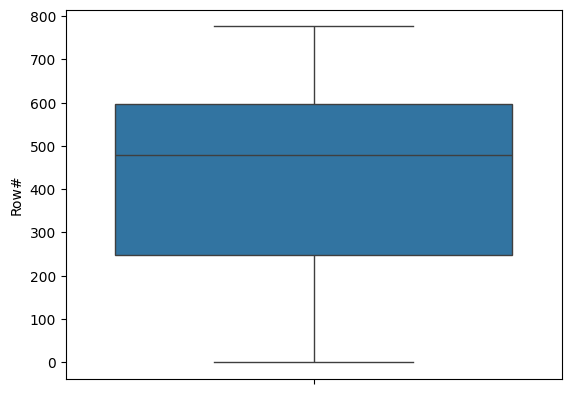

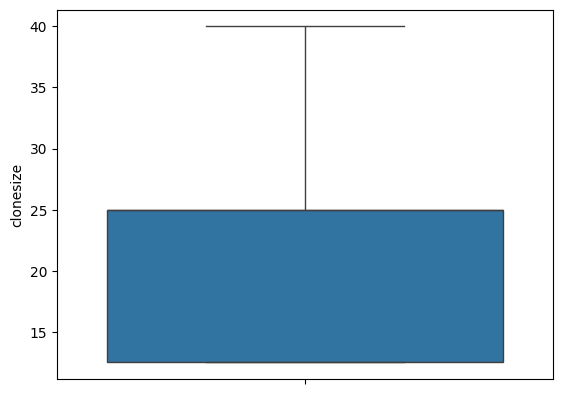

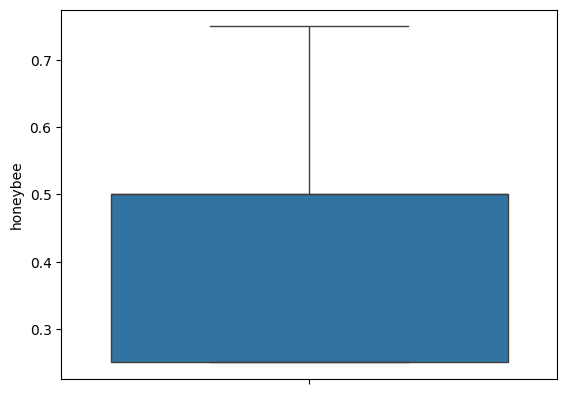

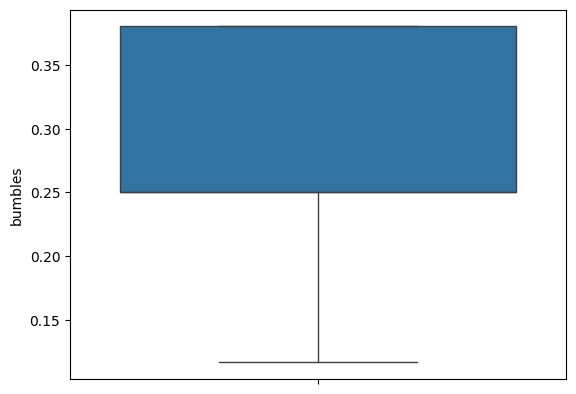

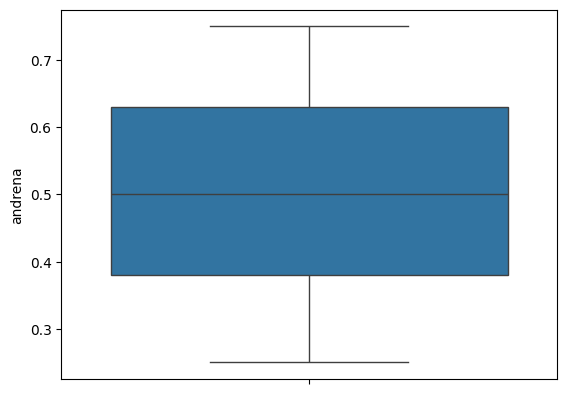

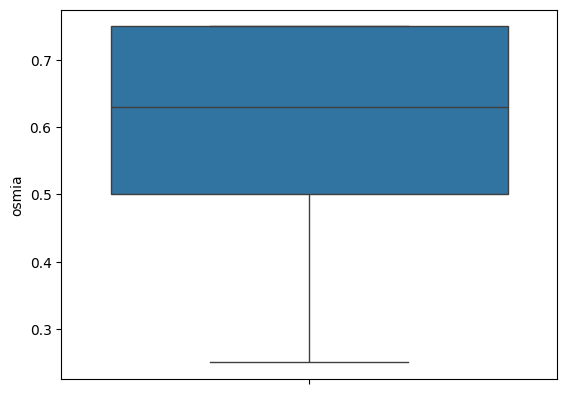

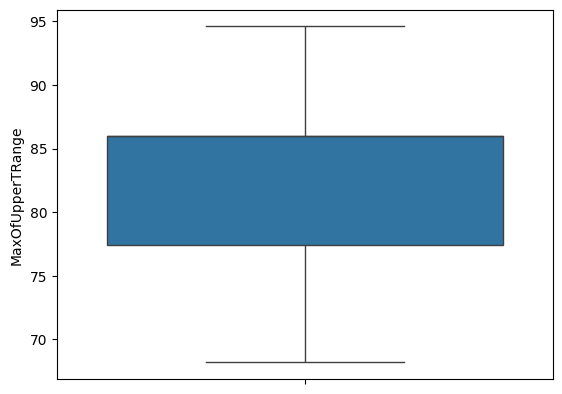

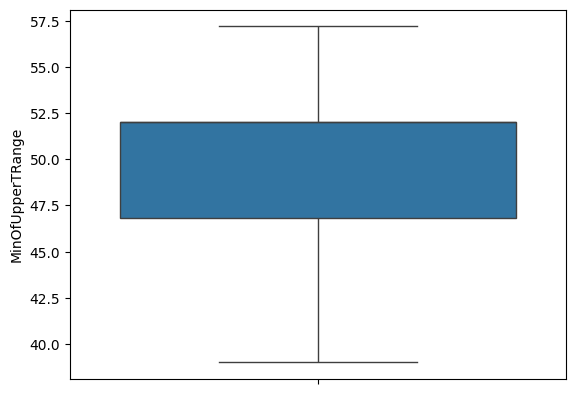

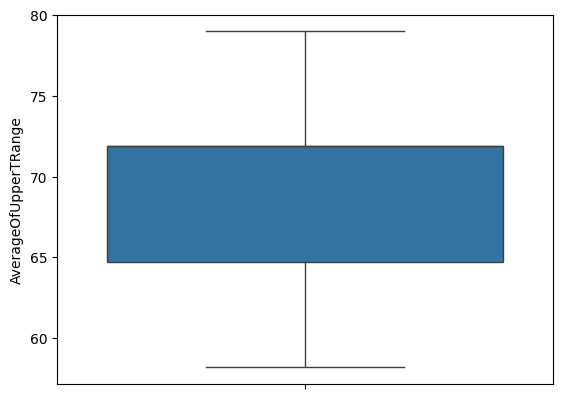

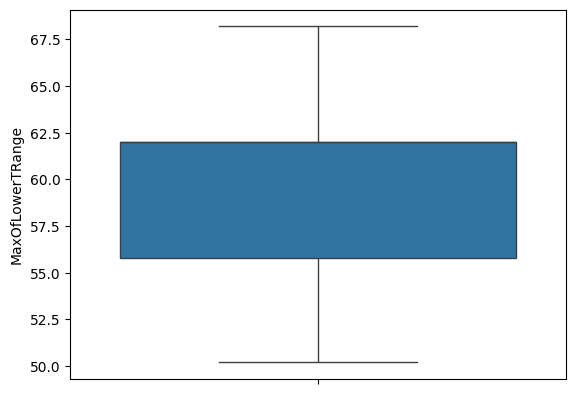

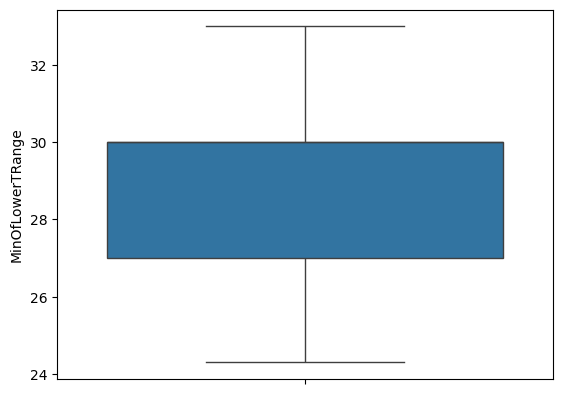

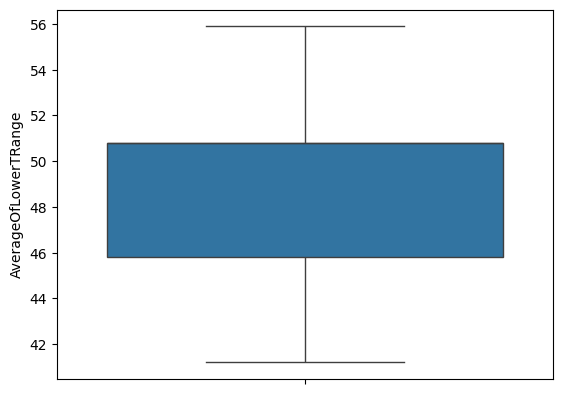

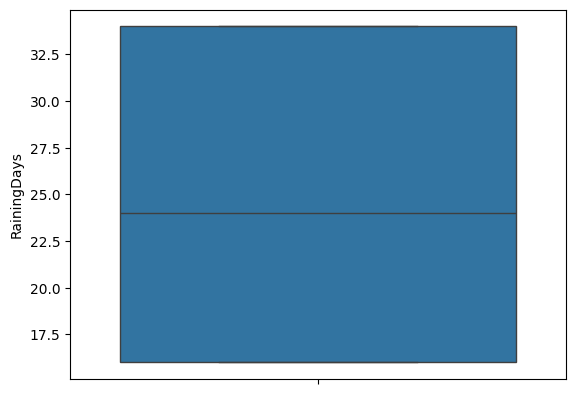

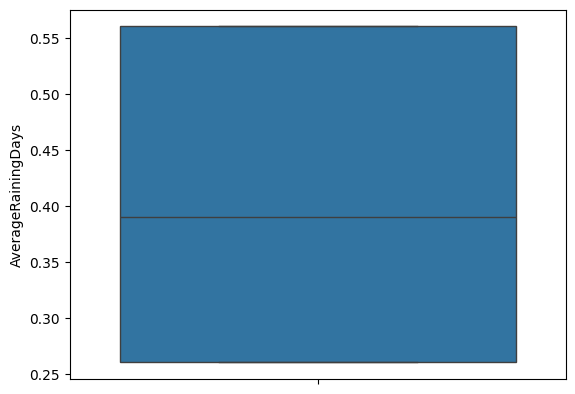

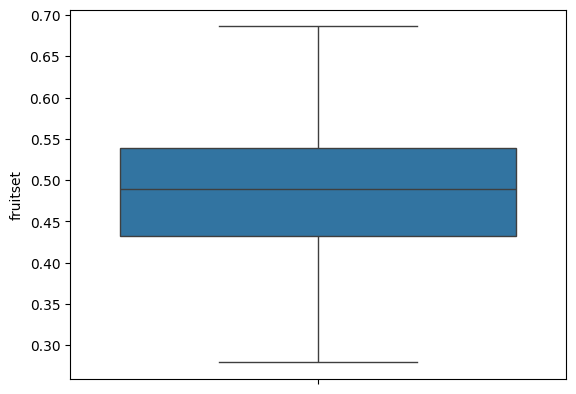

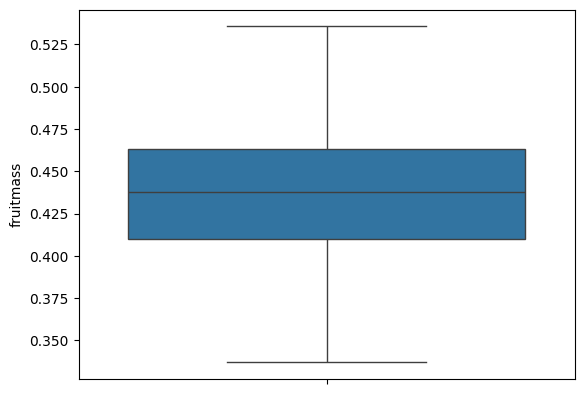

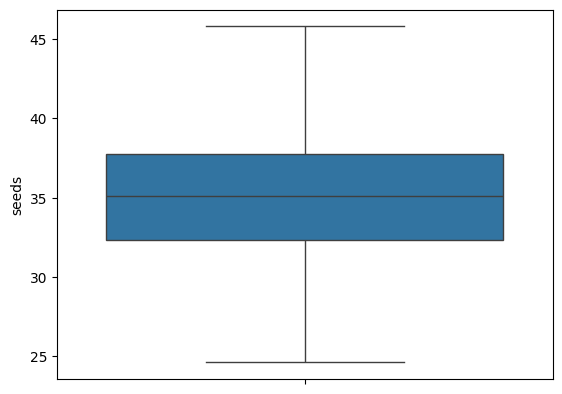

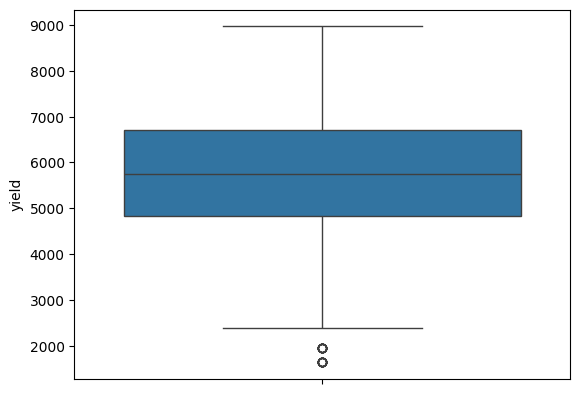

In [11]:
for x in df.columns:
  sns.boxplot(df[x])
  plt.show()


**Correlation Using Heatmap**

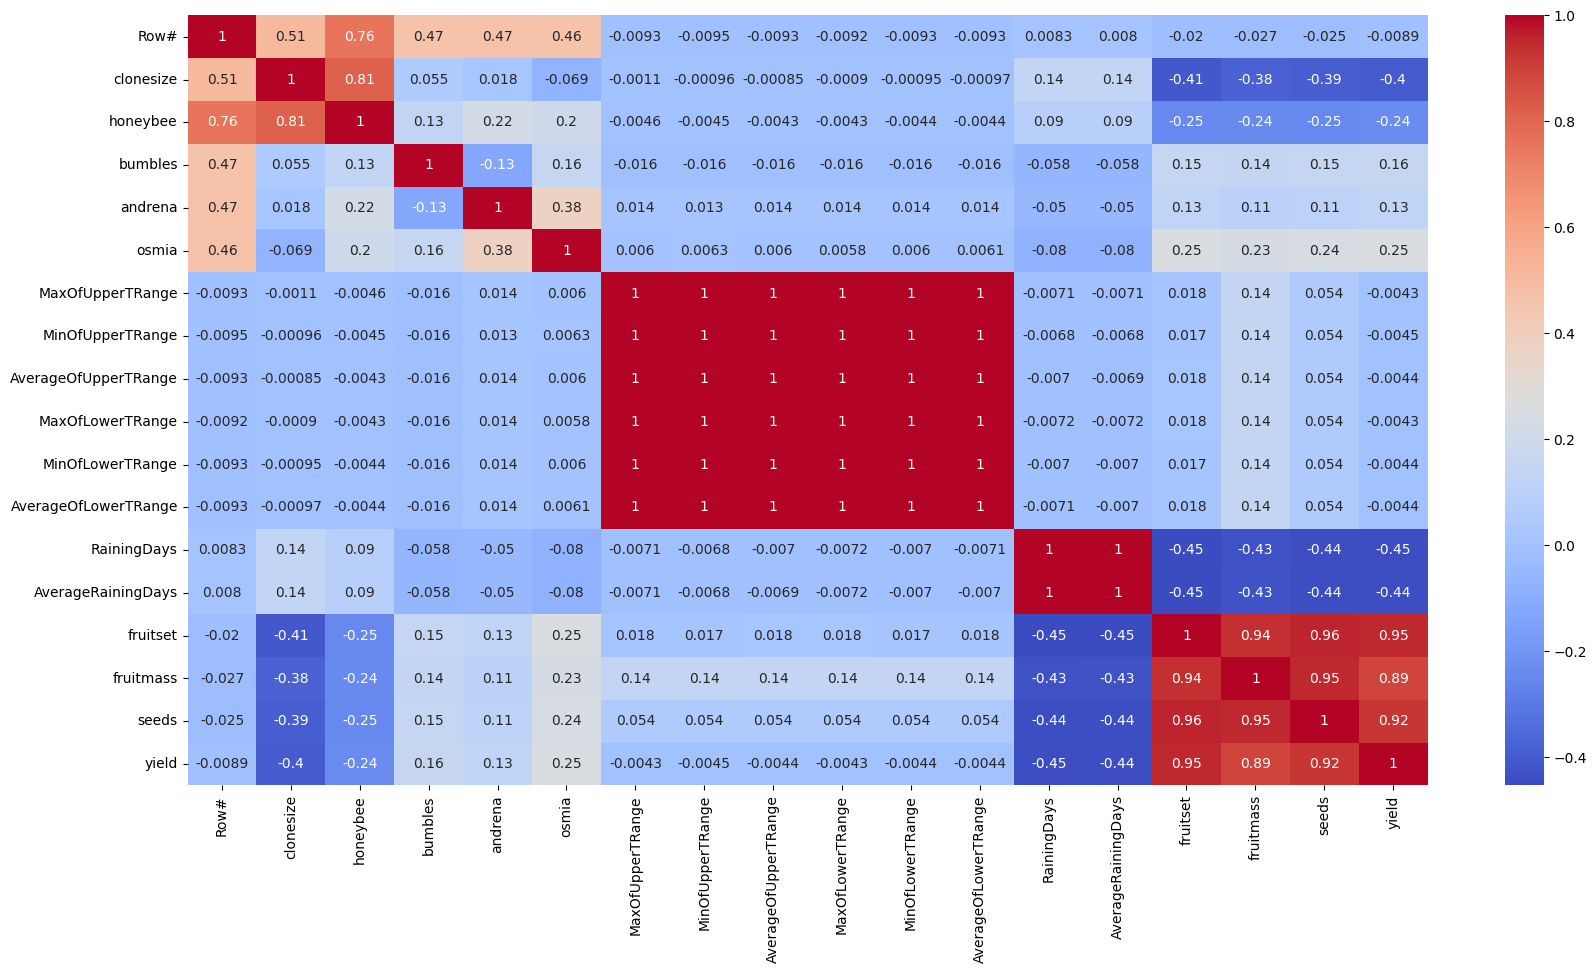

In [14]:
corrMat = df.corr(numeric_only=True)
plt.figure(figsize=(20,10))
sns.heatmap(data = corrMat, annot = True, cmap='coolwarm')
plt.show()

###**Model Training**

In [19]:
X=df.drop(columns = 'yield')
y = df['yield']
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.3, random_state=42)

Implementing Linear Regression From Scratch

In [56]:
class ClosedFormLinearRegression:
  def __init__(self):
    self.beta = None

  def fit(self, X, y):
    ones = np.ones((X.shape[0],1))
    Xb = np.hstack((ones, X))

    self.beta = np.linalg.inv((Xb.T) @ Xb) @ (Xb.T) @ y
    print('Model Created')

  def predict(self, X):
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack((ones, X))
    return X_b @ self.beta

In [57]:
scratch_model = ClosedFormLinearRegression()
scratch_model.fit(X_train, y_train)

Model Created


In [59]:
y_pred_scratch = scratch_model.predict(X_test)

In [60]:
print(f'r2-score is {r2_score(y_pred_scratch, y_test)}')

r2-score is 0.8903387443324008


Using sklearn Library

In [20]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X_train,y_train)

LinearRegression()

In [22]:
y_pred = sklearn_model.predict(X_test)

In [35]:
print(f'r2-score is {r2_score(y_pred, y_test)}')

r2-score is 0.8903387416670815
